In [71]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics


In [73]:
df =pd.read_csv('data_titanic.csv',header = 'infer')
print(df.shape)
df.head(3)

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [74]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [75]:
## Borramos los null 
n = df.shape[0] # filas  
# lista de edades que se llenara cada vez que se aga una iteracion
age = []
for i in range(n):
    if np.isnan(df.Age[i]):
        if ('Mr' in df.Name[i]) or ('Mrs' in df.Name[i]):  # te preguntas si es mujer o hombre
            age.append(30)  
        else : 
            age.append(10)
    else: 
        age.append(df.Age[i])

df.Age = pd.Series(age)

In [76]:
# Eliminamos columnas que no se van a utilizar 
df = df.drop(columns = ['PassengerId','Name','Ticket','Cabin','Fare'])
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S


In [77]:
# Eliminar los valores faltantes del conjunto 
df = df.dropna(axis = 0)  #axis 0 columnas 
df.shape  

(889, 7)

<Axes: xlabel='Survived', ylabel='count'>

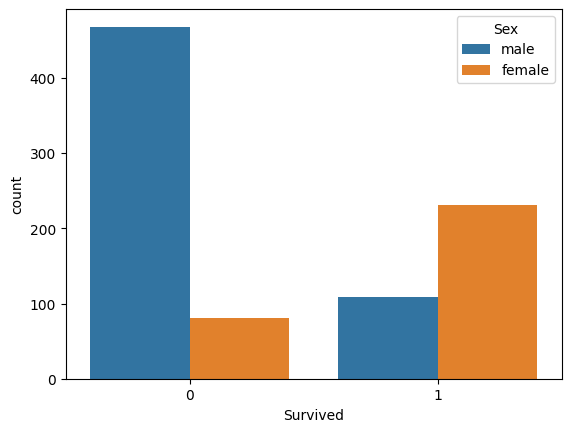

In [78]:
## crear un grafico de barras donde muestre si sobrevivieron o no  

sns.countplot(x = 'Survived', hue = 'Sex', data=df)

C:\Users\6570\AppData\Local\Temp\ipykernel_18676\3610462893.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x = 'AgeCategory', y = 'Survived', ci = None, data = df)


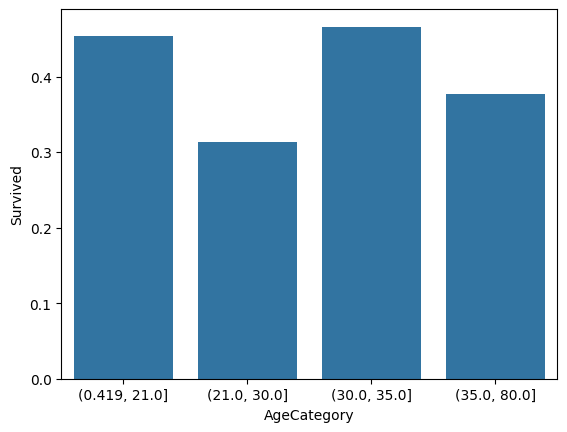

In [79]:
# categorizar edades 
df['AgeCategory'] = pd.qcut(df.Age,4) # divide en 4 categorias a las edades 
sns.barplot(x = 'AgeCategory', y = 'Survived', ci = None, data = df)
plt.show()

In [80]:
#Ingenieria de caracteristicas 
#df.head()
df = pd.get_dummies(df.AgeCategory, drop_first =True, prefix='Age').join(df.drop(columns=['Age','AgeCategory'])) 
df = pd.get_dummies(df.Pclass, drop_first =True, prefix='Pclass').join(df.drop(columns=['Pclass']))
df = pd.get_dummies(df.SibSp, drop_first =True, prefix='SibSp').join(df.drop(columns=['SibSp']))
df = pd.get_dummies(df.Parch, drop_first =True, prefix='Parc').join(df.drop(columns=['Parch']))
df = pd.get_dummies(df.Sex, drop_first =True, prefix='Sex').join(df.drop(columns=['Sex']))
df = pd.get_dummies(df.Embarked, drop_first =True, prefix='Embarked').join(df.drop(columns=['Embarked']))

df.head(3)


,Embarked_Q,Embarked_S,Sex_male,Parc_1,Parc_2,Parc_3,Parc_4,Parc_5,Parc_6,SibSp_1,...,SibSp_3,SibSp_4,SibSp_5,SibSp_8,Pclass_2,Pclass_3,"Age_(21.0, 30.0]","Age_(30.0, 35.0]","Age_(35.0, 80.0]",Survived
0,False,True,True,False,False,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,0
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,1
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,1


In [ ]:
# Gurda en un nuevo archivo csv
df.to_csv('data_clean.csv',index=False)

In [96]:
## separamos en dos variables  independientes y  objetivo 

X = df.drop(columns = ['Survived'])
Y = df.Survived

In [94]:
#separamos en dos conjuntos de entrenamiento y prueba 
X_train, X_test, y_train,y_test, =train_test_split(X,Y ,test_size =0.3 , random_state = 1234)

In [ ]:
## entrenamiento del modelo con 5 vecinos 
knn5 = KNeighborsClassifier(n_neighbors = 5)
knn5.fit(X_train, y_train)
y_pred5 = knn5.predict(X_test)

print(metrics.confusion_matrix(y_test,y_pred5))
print('\n','Accuracy (K = 5): '+ str(np.round(metrics.accuracy_score(y_test,y_pred5),3)))


[[141  17]
 [ 42  67]]

 Accuracy (K = 5): 0.779


In [98]:
## entrenamiento del modelo con 5 vecinos 
knn100 = KNeighborsClassifier(n_neighbors = 100)
knn100.fit(X_train, y_train)
y_pred100 = knn100.predict(X_test)

print(metrics.confusion_matrix(y_test,y_pred100))
print('\n','Accuracy (K = 100): '+ str(np.round(metrics.accuracy_score(y_test,y_pred100),3)))

[[155   3]
 [ 56  53]]

 Accuracy (K = 100): 0.779


In [99]:
accs =[] #lista 
K_grids = range(1,20,1)
for k in K_grids:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    acc = metrics.accuracy_score(y_test,y_pred)
    accs.append(acc)
    

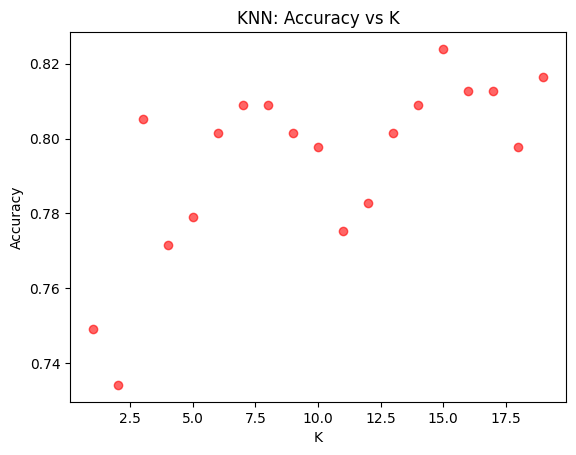

In [100]:
plt.scatter(K_grids,accs,c='red',marker='o',alpha=0.6)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs K')
plt.show()